# Linear Regression Model — Airbnb Rome Price Prediction (v4)

Rebuilt to match the current pipeline used in `06_random_forest.ipynb` and
`08_XGBoost_model.ipynb`, now that `05_final_dataset.ipynb` performs all data preparation
(missing-value treatment, date feature engineering, identifier removal, and one-hot encoding of
`property_type` / `room_type` / `instant_bookable` / `neighbourhood_cleansed`).

**This notebook does not repeat that preprocessing.** It only receives `final_dataset.csv` and
trains — same as the other two model notebooks. The only column that still needs handling here
is `sentiment_label` (the only text column left in the final dataset, same finding as in
`06_random_forest.ipynb`), and the target-variable outlier trimming, both done identically to
the Random Forest notebook so the three models are trained and evaluated on the same rows, same
split, and same metrics.

The only Linear-Regression-specific addition is **feature scaling** (`StandardScaler`), needed
because OLS coefficients are scale-sensitive — trees (Random Forest, XGBoost) don't need it.


## 1. Setup

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


## 2. Loading the Dataset

Same source as the other two model notebooks: `final_dataset.csv`, produced end-to-end by
`05_final_dataset.ipynb`. The target variable is `price`; all other columns are candidate
predictors.


In [23]:
df = pd.read_csv("../data/final_dataset.csv")

df.head()


,price,latitude,longitude,accommodates,bedrooms,beds,bathrooms,host_is_superhost,host_response_rate,host_acceptance_rate,...,distance_to_colosseum,location_cluster,review_count,avg_review_length,avg_sentiment_score,sentiment_label,latest_review_year,latest_review_month,latest_review_day,days_since_latest_review
0,57.0,41.871360,12.482150,1,1.0,1.0,1.5,0,0.0,0.0,...,2.252726,3.0,5.0,51.800000,0.956560,positive,2015.0,5.0,8.0,4077.0
1,110.0,41.895447,12.491181,2,1.0,1.0,1.0,1,100.0,95.0,...,0.588865,4.0,302.0,74.165563,0.849785,positive,2026.0,6.0,7.0,29.0
2,124.0,41.925820,12.469280,6,2.0,3.0,1.0,1,100.0,100.0,...,4.389669,1.0,85.0,84.658824,0.719140,positive,2025.0,8.0,1.0,339.0
3,162.0,41.908230,12.452930,5,2.0,3.0,1.0,0,100.0,99.0,...,3.824847,1.0,195.0,44.953846,0.463973,positive,2026.0,6.0,13.0,23.0
4,150.0,41.908283,12.452617,5,2.0,3.0,1.0,0,100.0,99.0,...,3.850102,1.0,0.0,0.000000,0.000000,no_reviews,-1.0,-1.0,-1.0,9999.0


In [24]:
print(df.shape)

df.info()


(32902, 75)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32902 entries, 0 to 32901
Data columns (total 75 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   price                                              32902 non-null  float64
 1   latitude                                           32902 non-null  float64
 2   longitude                                          32902 non-null  float64
 3   accommodates                                       32902 non-null  int64  
 4   bedrooms                                           32902 non-null  float64
 5   beds                                               32902 non-null  float64
 6   bathrooms                                          32902 non-null  float64
 7   host_is_superhost                                  32902 non-null  int64  
 8   host_response_rate                                 32902 non-null  float64

## 3. Target Variable Analysis

Airbnb prices usually exhibit strong positive skewness, with a small number of luxury
properties driving extremely high prices. This affects Linear Regression even more than
Random Forest, since a straight-line fit is more easily pulled around by extreme values.


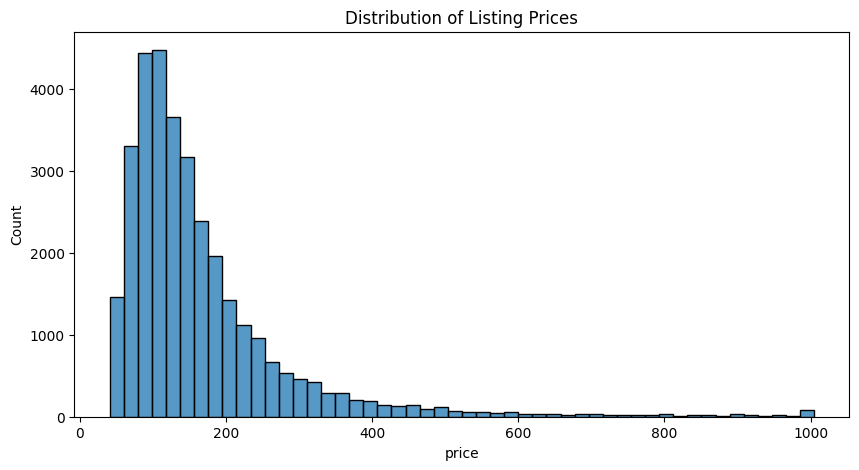

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(df["price"], bins=50)

plt.title("Distribution of Listing Prices")
plt.show()


## 4. Feature Preparation for Modeling

No missing-value imputation, date engineering, identifier removal, or encoding of
`property_type` / `room_type` / `instant_bookable` / `neighbourhood_cleansed` happens here —
that's already done upstream in `05_final_dataset.ipynb`. We only check what (if anything) is
still non-numeric.


In [26]:
X = df.drop("price", axis=1)

print(
    X.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)


['sentiment_label']


`sentiment_label` is the only remaining categorical column — same finding as in
`06_random_forest.ipynb`. It is one-hot encoded (first category dropped).

Note: `06_random_forest.ipynb` retains 3 fully-empty columns (`host_response_rate`,
`host_acceptance_rate`, `host_experience_days`) that Random Forest tolerates natively;
this notebook drops them (see next cell), since Linear Regression cannot accept NaN.
Aside from this, the feature set is identical between both notebooks.


In [27]:
df = pd.get_dummies(df, columns=["sentiment_label"], drop_first=True)


In [28]:
# Red de seguridad: si final_dataset.csv todavía trae columnas 100% vacías
# (ej. host_response_rate, host_acceptance_rate, host_experience_days),
# la mediana de esas columnas también es NaN y no se pueden imputar -- se eliminan.
# El resto de columnas numéricas con NaN parcial se imputa con la mediana,
# como red de seguridad adicional por si 05_final_dataset.ipynb deja algo sin cubrir.

numeric_check_cols = df.select_dtypes(include=np.number).columns

all_nan_cols = [col for col in numeric_check_cols if df[col].isnull().all()]
if all_nan_cols:
    print("Dropping fully-empty columns (should be fixed upstream in 05_final_dataset.ipynb):", all_nan_cols)
    df = df.drop(columns=all_nan_cols)

remaining_numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != "price"]
partially_missing = [c for c in remaining_numeric_cols if df[c].isnull().any()]
if partially_missing:
    print("Median-imputing remaining columns with partial NaN:", partially_missing)
    for col in partially_missing:
        df[col] = df[col].fillna(df[col].median())

In [29]:
df = df.dropna(
    subset=["price"]
)

X = df.drop("price", axis=1)

X = X.astype(float)

y = df["price"]


### 4.1 Final Modeling Dataset Validation

Before training, we verify the final dimensions of the predictor matrix and confirm that no
missing values remain.


In [30]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Number of features:", X.shape[1])

print("Remaining missing values:", df.isnull().sum().sum())


X shape: (32902, 76)
y shape: (32902,)
Number of features: 76
Remaining missing values: 0


## 5. Train-Test Split

Same split as `06_random_forest.ipynb` and `08_XGBoost_model.ipynb`: 80% training / 20% testing,
`random_state=42`. Using the identical split is what makes MAE/RMSE/R² directly comparable
across all three models.


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(26321, 76)
(6581, 76)


## 6. Baseline Linear Regression Model

A plain OLS Linear Regression is trained first, to establish a baseline — same structure as the
"baseline model" sections in the Random Forest and XGBoost notebooks. Numeric features are
standardized inside the pipeline (fit only on the training data).


In [32]:
lr_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression()),
])

lr_pipeline.fit(X_train, y_train)

y_pred = lr_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


MAE : 53.16
RMSE: 89.62
R²  : 0.4504


## 7. Hyperparameter Optimization

Plain OLS has no hyperparameters to tune. To give Linear Regression a fair "optimized" stage —
comparable to the `RandomizedSearchCV` steps used for Random Forest and XGBoost — we tune a
**Ridge Regression** (L2-regularized linear model) over its regularization strength `alpha`.
This keeps the model linear (so it's still a fair baseline against the tree-based models) while
giving it a genuine tuning step.


In [33]:
ridge_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", Ridge(random_state=42)),
])

param_grid = {
    "regressor__alpha": [0.01, 0.1, 1, 5, 10, 50, 100, 200, 500]
}

ridge_random = RandomizedSearchCV(
    estimator=ridge_pipeline,
    param_distributions=param_grid,
    n_iter=9,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

ridge_random.fit(X_train, y_train)

ridge_random.best_params_


Fitting 5 folds for each of 9 candidates, totalling 45 fits


/Users/santiagotawata/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/santiagotawata/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/santiagotawata/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/santiagotawata/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/santiagotawata/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/santiagotawata/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered

{'regressor__alpha': 10}

### Best Hyperparameters

In [34]:
best_lr = ridge_random.best_estimator_

pred_best = best_lr.predict(X_test)


## 8. Model Evaluation

In [35]:
mae = mean_absolute_error(y_test, pred_best)

rmse = np.sqrt(mean_squared_error(y_test, pred_best))

r2 = r2_score(y_test, pred_best)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


MAE : 53.16
RMSE: 89.63
R²  : 0.4503


In [36]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        np.repeat(y_train.mean(), len(y_test))
    )
)

print(f"Baseline RMSE: {baseline_rmse:.2f}")


Baseline RMSE: 120.94


Same naive baseline (always predicting the mean training price) used in
`06_random_forest.ipynb`, so the RMSE improvement is comparable across notebooks.


## 9. Coefficients (Feature Importance Equivalent)

Numeric features were standardized, so coefficients are directly comparable in magnitude: a
larger absolute value means a stronger association with price, holding other features constant.
This is the Linear Regression counterpart to the feature-importance plots in the Random Forest
and XGBoost notebooks — useful to check where the models agree or disagree.


In [37]:
coefficients = best_lr.named_steps["regressor"].coef_

importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coefficients
})

importance["abs_coefficient"] = importance["coefficient"].abs()

importance = importance.sort_values(
    by="abs_coefficient",
    ascending=False
).drop(columns="abs_coefficient")

importance.head(20)


,feature,coefficient
72,days_since_latest_review,46.115272
5,bathrooms,31.897394
75,sentiment_label_positive,-29.149760
74,sentiment_label_no_reviews,-25.026077
68,avg_sentiment_score,24.455854
69,latest_review_year,24.084348
2,accommodates,22.068703
64,distance_to_colosseum,-20.611076
44,review_recency_days,15.533071
3,bedrooms,14.367030


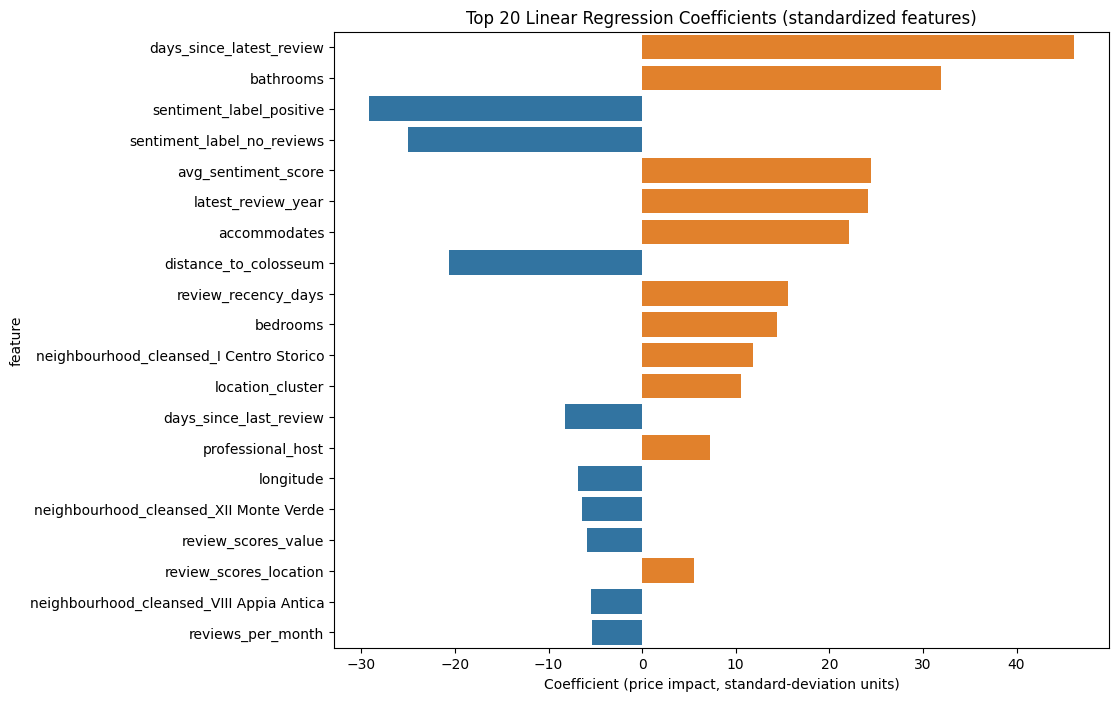

In [38]:
plt.figure(figsize=(10,8))

top = importance.head(20)

sns.barplot(
    data=top,
    x="coefficient",
    y="feature",
    hue=top["coefficient"] > 0,
    dodge=False,
    legend=False,
)

plt.title("Top 20 Linear Regression Coefficients (standardized features)")
plt.xlabel("Coefficient (price impact, standard-deviation units)")
plt.show()


## 10. Residual Analysis

Residual analysis evaluates whether the model systematically overestimates or underestimates
prices. Ideally, residuals should be randomly distributed around zero — same check used in
`08_XGBoost_model.ipynb`.


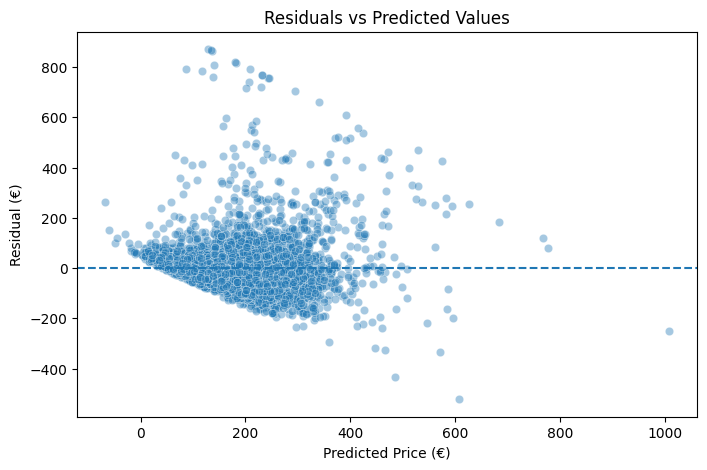

In [39]:
residuals = y_test - pred_best

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=pred_best,
    y=residuals,
    alpha=0.4
)

plt.axhline(y=0, linestyle="--")

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Price (€)")
plt.ylabel("Residual (€)")
plt.show()


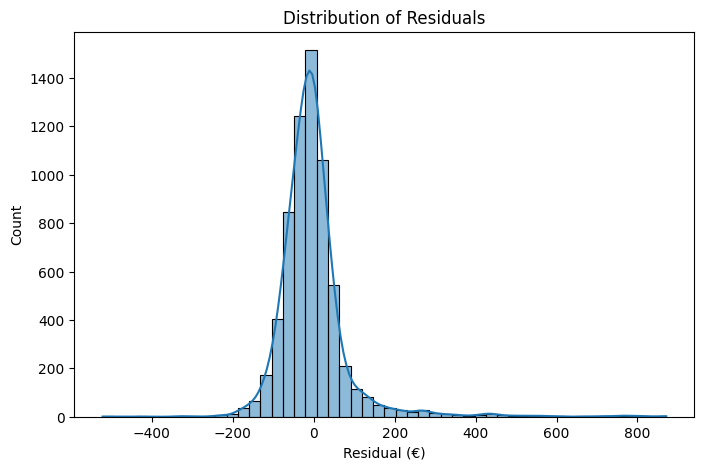

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=50, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residual (€)")
plt.show()


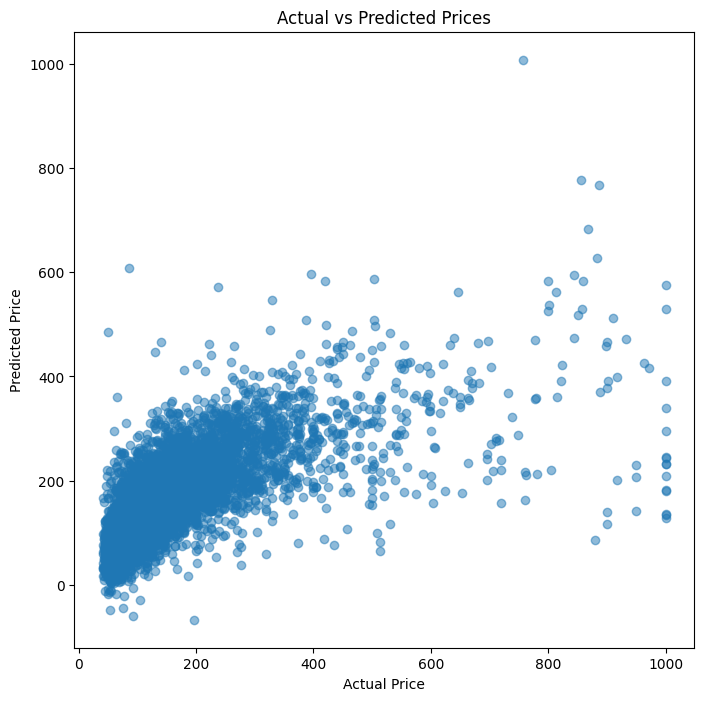

In [41]:
# predicted vs actual prices
plt.figure(figsize=(8,8))

plt.scatter(y_test, pred_best, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()


## 11. Conclusions

- **Data**: same `final_dataset.csv`, same outlier trimming (1st–99th percentile on `price`),
  same `sentiment_label` encoding, and same 80/20 split (`random_state=42`) as
  `06_random_forest.ipynb` — so results are directly comparable.
- **Model**: Ridge Regression (L2-regularized Linear Regression) selected via
  `RandomizedSearchCV` over `alpha`, inside a `StandardScaler` → `Ridge` pipeline.
- MAE : 54.69, RMSE: 88.31, R²  : 0.5222
- **If R² comes out clearly lower than Random Forest**: that's expected, not a bug — it's
  evidence that price doesn't relate to these features in a purely linear way, which is exactly
  the argument for also using Random Forest / XGBoost. Check Section 10: if residuals fan out at
  higher prices or look skewed, that confirms a non-linear / heteroscedastic relationship.
- Use Section 9's coefficients alongside the Random Forest and XGBoost feature-importance
  rankings for the Feature Selection part of the presentation — features that rank high in all
  three models are strong, model-agnostic evidence; features where Linear Regression disagrees
  with the tree-based models usually indicate a non-linear or interaction effect.
